# Quintessence/K-essence

Let's explore the solutions for $\alpha_B$ and $\mu$ assuming a form for $\alpha_K$ akin to quintessence,

\begin{equation}
    \alpha_K = \Omega_\mathrm{DE}(1 + w)/c_s^2
\end{equation}

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from engine import *

## One Cosmology

Text(0, 0.5, '$\\mu$')

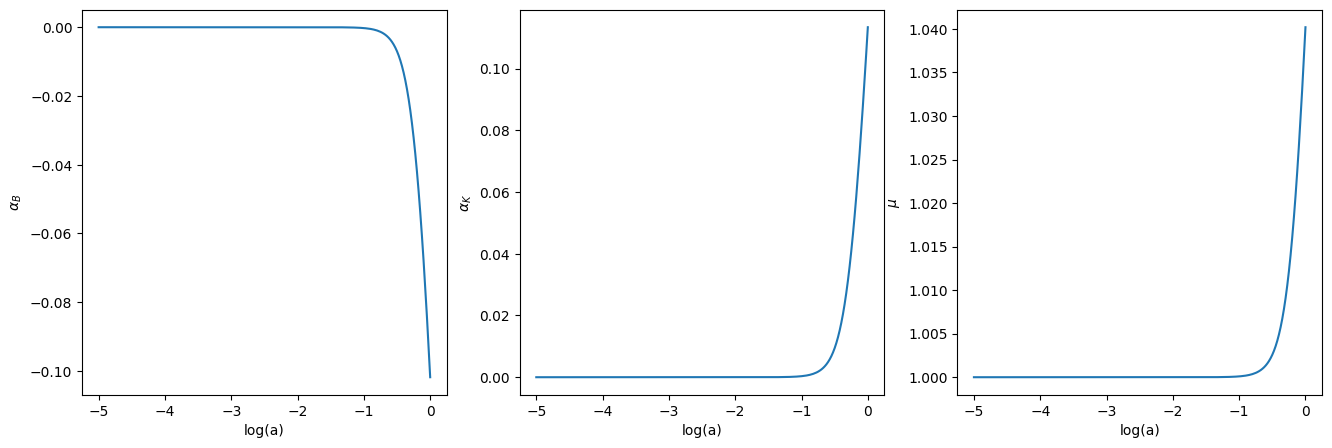

In [2]:
reference_cosmo = {
    "omega_m": 0.3,
    "w0": -0.838,
    "wa": -0.1,
    "cs2": 1,
    "cs2_a": 0,
    "alpha_K_0": 1,
}

log_a, alpha_B, alpha_K, mu = solve_alpha_B(aktype=alphaKtype.QUINT, **reference_cosmo)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].plot(log_a, alpha_B)
axs[0].set_xlabel("log(a)")
axs[0].set_ylabel("$\\alpha_B$")
axs[1].plot(log_a, alpha_K)
axs[1].set_xlabel("log(a)")
axs[1].set_ylabel("$\\alpha_K$")
axs[2].plot(log_a, mu)
axs[2].set_xlabel("log(a)")
axs[2].set_ylabel("$\\mu$")

## Sampling across parameter space

### 1. Star Sampling

/home/joao/cosmo/cs2-project/mu_solutions_study/engine.py:59: RuntimeWarning: divide by zero encountered in scalar divide
  return alpha_K_0*omega_de*(1 + w_de)/(cs2 + cs2_a*(1-a))
/home/joao/cosmo/cs2-project/mu_solutions_study/engine.py:92: RuntimeWarning: invalid value encountered in scalar multiply
  return (cs2 + cs2_a*(1-a))*(alpha_K + 1.5*alpha_B**2) + 0.5*alpha_B**2 - alpha_B*(d_lnH_d_lna + 1) - 3*(1 + wde)*rhode/rhotot


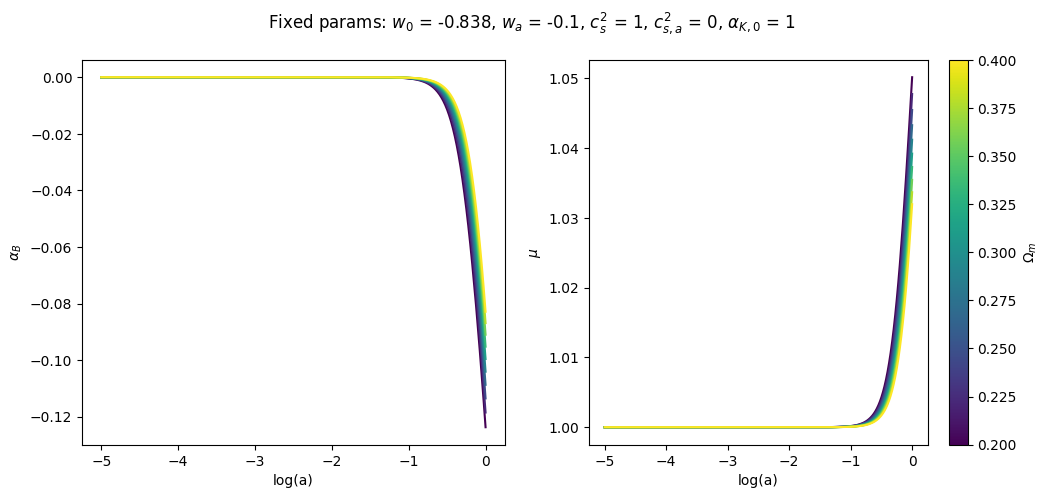

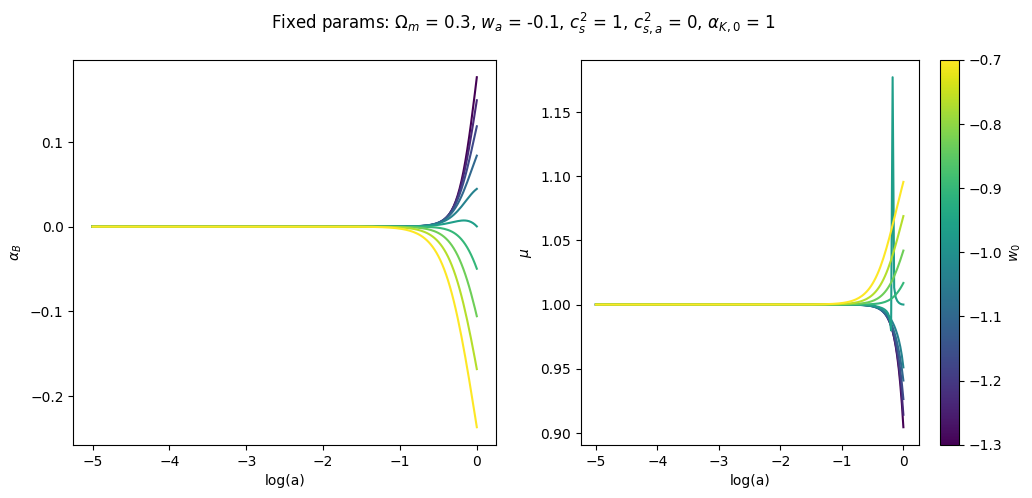

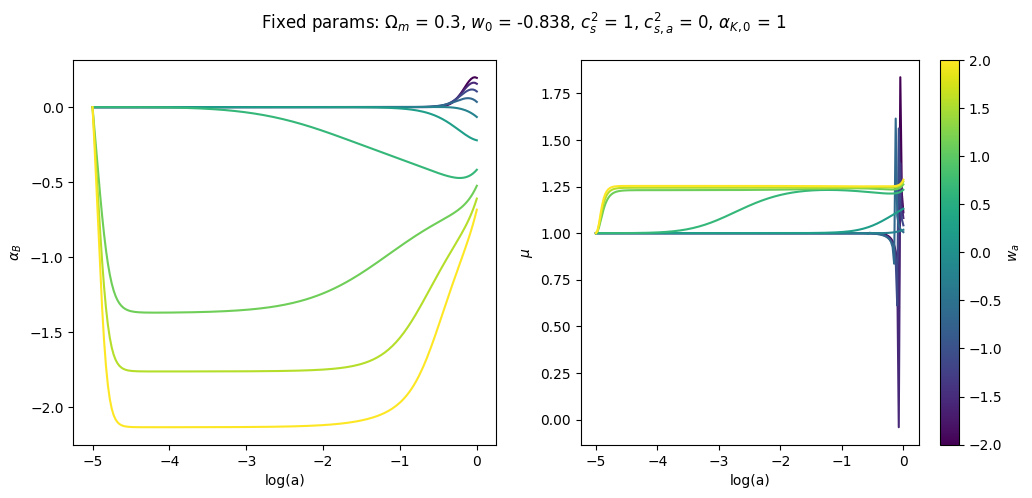

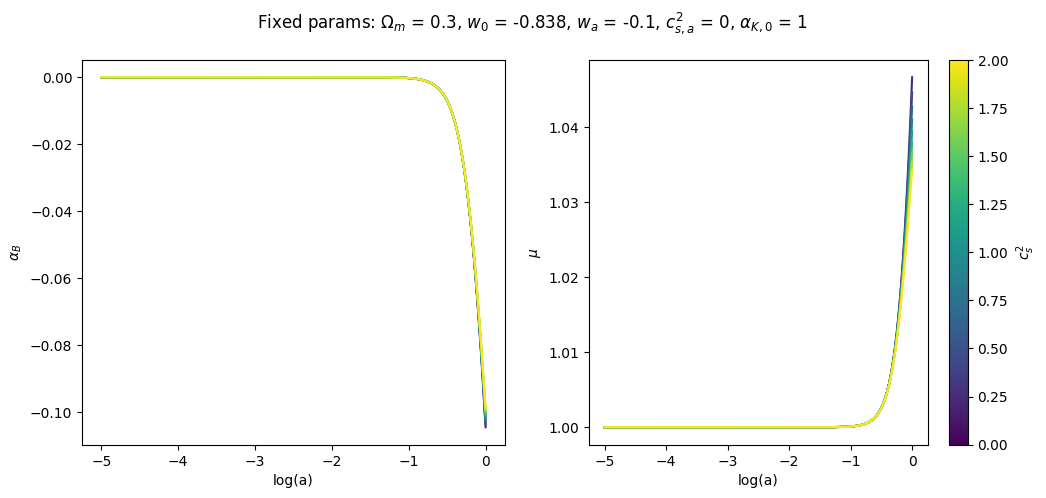

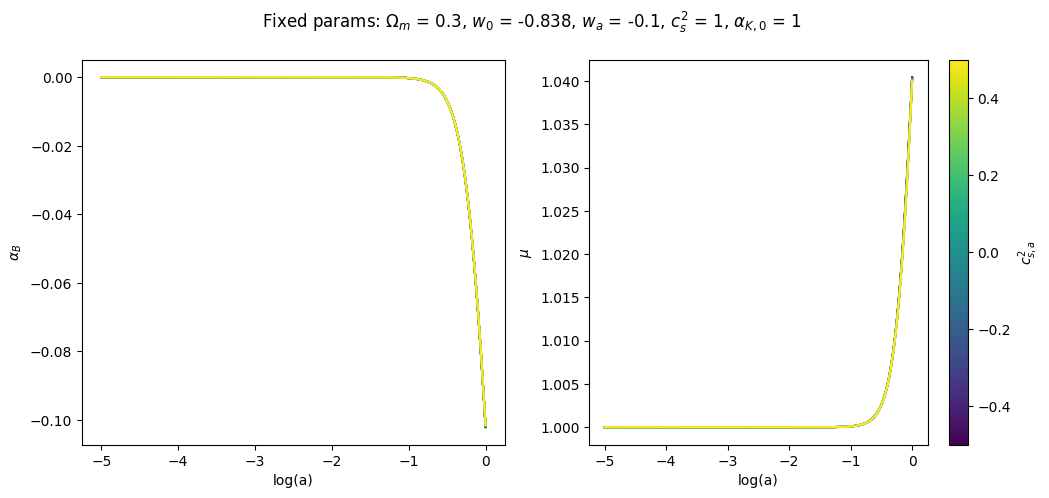

In [3]:
grids = {
    "omega_m": np.linspace(0.2, 0.4, 10),
    "w0"     : np.linspace(-1.3, -0.7, 10),
    "wa"     : np.linspace(-2, 2, 10),
    "cs2"    : np.linspace(0, 2, 10),
    "cs2_a"    : np.linspace(-0.5, 0.5, 10),
}

cmap = plt.get_cmap('viridis')

for param_name in grids.keys():
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    params = reference_cosmo.copy()
    norm = mpl.colors.Normalize(vmin=grids[param_name][0], vmax=grids[param_name][-1])
    for param_value in grids[param_name]:
        params[param_name] = param_value
        loga, alpha_B, alpha_K, mu = solve_alpha_B(aktype=alphaKtype.QUINT, **params)
        color = cmap(norm(param_value))
        axs[0].plot(loga, alpha_B, color=color)
        axs[1].plot(loga, mu, color=color)
    for ax in axs:
        ax.set_xlabel("log(a)")
    axs[0].set_ylabel("$\\alpha_B$")
    axs[1].set_ylabel("$\\mu$")
    
    del params[param_name]
    title = ", ".join([" = ".join((param_name_latex[name], f"{value}")) for (name, value) in params.items()])
    fig.suptitle(f"Fixed params: {title}")

    # Create a ScalarMappable for the colorbar (no data required)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # for colorbar compatibility

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(param_name_latex[param_name])
    plt.savefig(f"plots/quint/{param_name}_scan.pdf")

### 2. Random Sampling

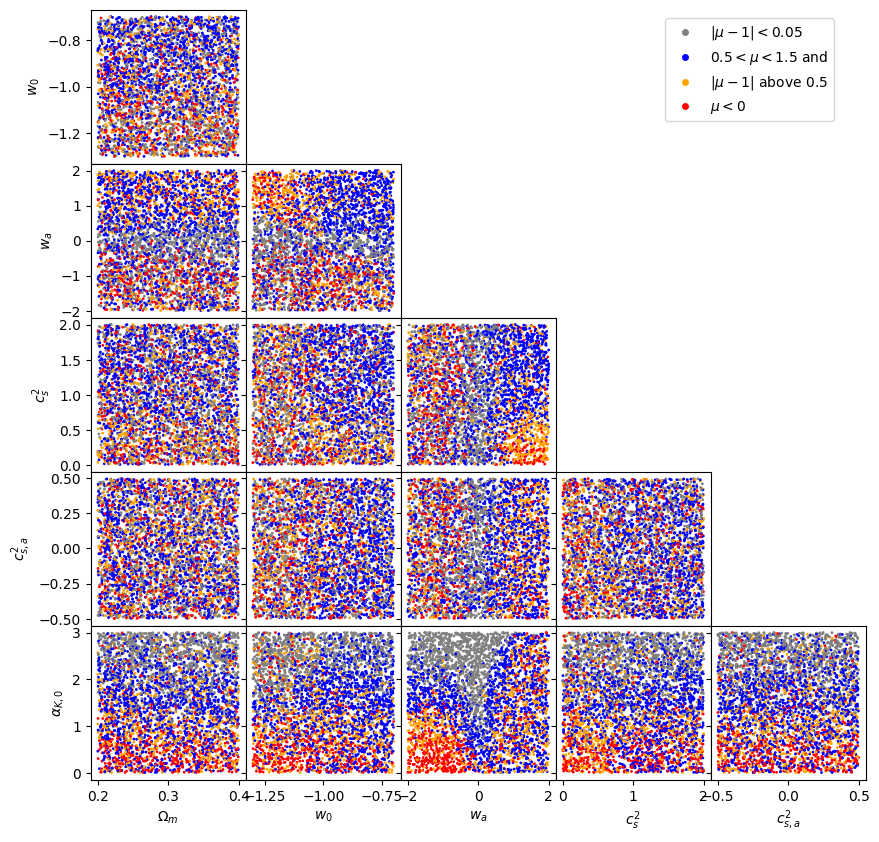

In [4]:
priors = {
    "omega_m"  : [0.2, 0.4],
    "w0"       : [-1.3, -0.7],
    "wa"       : [-2, 2],
    "cs2"      : [0, 2],
    "cs2_a"      : [-0.5, 0.5],
    "alpha_K_0": [0, 3],
}

plot_scatter(alphaKtype.QUINT, priors, "plots/quint/alpha_B_samples.pdf")